# Regression Data Visualization and Analysis

This notebook provides comprehensive visualizations for the regression dataset to understand data patterns, distributions, temporal trends, and relationships between features.

**Dataset:** Combined commercial banks stock price data

**Purpose:** Exploratory data analysis for regression modeling

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("Libraries imported successfully")

Libraries imported successfully


## 2. Load Data

In [2]:
# Load combined dataset
data = pd.read_csv('../data_preprocessing/combined_banks_dataset.csv')
data['published_date'] = pd.to_datetime(data['published_date'])
data = data.sort_values(['company_id', 'published_date']).reset_index(drop=True)

print(f"Dataset shape: {data.shape}")
print(f"Number of banks: {data['company_id'].nunique()}")
print(f"Date range: {data['published_date'].min()} to {data['published_date'].max()}")
print(f"\nColumns: {list(data.columns)}")

Dataset shape: (53063, 10)
Number of banks: 17
Date range: 2009-06-25 00:00:00 to 2025-12-29 00:00:00

Columns: ['published_date', 'open', 'high', 'low', 'close', 'per_change', 'traded_quantity', 'traded_amount', 'status', 'company_id']


In [3]:
# Display first few rows
data.head(10)

,published_date,open,high,low,close,per_change,traded_quantity,traded_amount,status,company_id
0,2010-09-16,117.0,122.0,116.0,120.0,NaN,5280.0,0.0,0,ADBL
1,2010-09-19,120.0,120.0,116.0,118.0,-1.67,2648.0,0.0,0,ADBL
2,2010-09-20,118.0,119.0,116.0,118.0,0.00,2346.0,0.0,0,ADBL
3,2010-09-21,118.0,118.0,115.0,116.0,-1.69,7160.0,0.0,0,ADBL
4,2010-09-23,116.0,120.0,117.0,120.0,3.45,8417.0,0.0,0,ADBL
5,2010-09-26,120.0,122.0,117.0,121.0,0.83,9541.0,0.0,0,ADBL
6,2010-09-27,121.0,122.0,116.0,119.0,-1.65,10433.0,0.0,0,ADBL
7,2010-09-28,119.0,120.0,119.0,119.0,0.00,2682.0,0.0,0,ADBL
8,2010-09-29,119.0,120.0,117.0,119.0,0.00,2561.0,0.0,0,ADBL
9,2010-09-30,119.0,120.0,117.0,119.0,0.00,1912.0,0.0,0,ADBL


In [4]:
# Dataset information
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53063 entries, 0 to 53062
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   published_date   53063 non-null  datetime64[ns]
 1   open             53063 non-null  float64       
 2   high             53063 non-null  float64       
 3   low              53063 non-null  float64       
 4   close            53063 non-null  float64       
 5   per_change       53046 non-null  float64       
 6   traded_quantity  53063 non-null  float64       
 7   traded_amount    53063 non-null  float64       
 8   status           53063 non-null  int64         
 9   company_id       53063 non-null  object        
dtypes: datetime64[ns](1), float64(7), int64(1), object(1)
memory usage: 4.0+ MB


In [5]:
# Statistical summary
data.describe()

,published_date,open,high,low,close,per_change,traded_quantity,traded_amount,status
count,53063,53063.000000,53063.000000,53063.000000,53063.000000,53046.000000,5.306300e+04,5.306300e+04,53063.000000
mean,2018-12-04 02:27:18.158415360,559.953382,567.179590,552.082047,559.515350,0.034534,4.876580e+04,1.978984e+07,-0.084353
min,2009-06-25 00:00:00,98.000000,100.000000,98.000000,98.000000,-72.740000,1.000000e+01,0.000000e+00,-1.000000
25%,2015-06-07 00:00:00,262.000000,266.000000,258.000000,261.000000,-0.970000,5.513500e+03,2.831650e+06,-1.000000
50%,2018-12-23 00:00:00,399.000000,404.000000,392.000000,398.000000,0.000000,1.778700e+04,7.640956e+06,0.000000
75%,2022-07-21 00:00:00,614.000000,620.000000,605.000000,612.875000,0.870000,5.140150e+04,1.940470e+07,0.000000
max,2025-12-29 00:00:00,3895.000000,3952.000000,3800.000000,3895.000000,130.340000,2.489844e+06,1.179786e+09,1.000000
std,NaN,510.813948,517.203253,505.048434,511.400241,2.362701,9.690847e+04,3.908727e+07,0.722001


## 3. Missing Values Analysis

In [6]:
# Check for missing values
missing = data.isnull().sum()
missing_pct = (missing / len(data)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Percentage': missing_pct
})

print("Missing Values:")
print(missing_df[missing_df['Missing Count'] > 0])

if missing.sum() == 0:
    print("\nNo missing values found")

Missing Values:
            Missing Count  Percentage
per_change             17    0.032037


## 4. Data Distribution per Bank

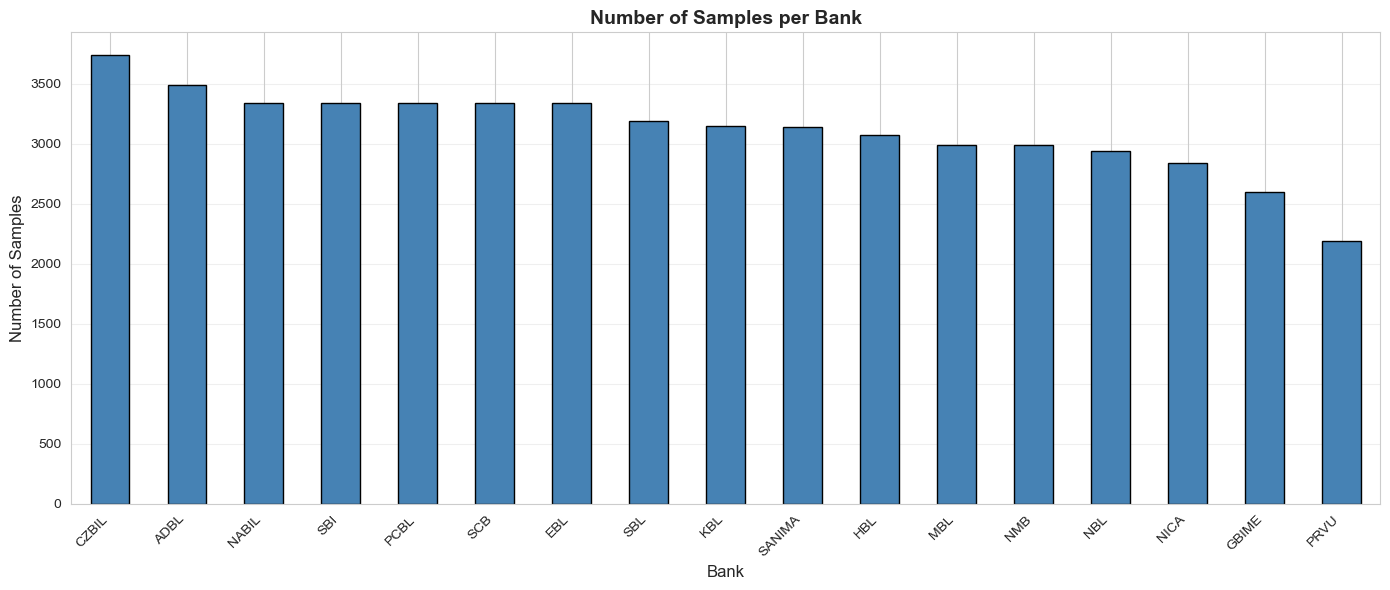


Total samples: 53,063
Average samples per bank: 3121
Median samples per bank: 3150
Min samples: 2192
Max samples: 3742


In [7]:
# Sample count per bank
bank_counts = data['company_id'].value_counts().sort_values(ascending=False)

plt.figure(figsize=(14, 6))
bank_counts.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Number of Samples per Bank', fontsize=14, fontweight='bold')
plt.xlabel('Bank', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nTotal samples: {len(data):,}")
print(f"Average samples per bank: {bank_counts.mean():.0f}")
print(f"Median samples per bank: {bank_counts.median():.0f}")
print(f"Min samples: {bank_counts.min()}")
print(f"Max samples: {bank_counts.max()}")

## 5. Price Distribution Analysis

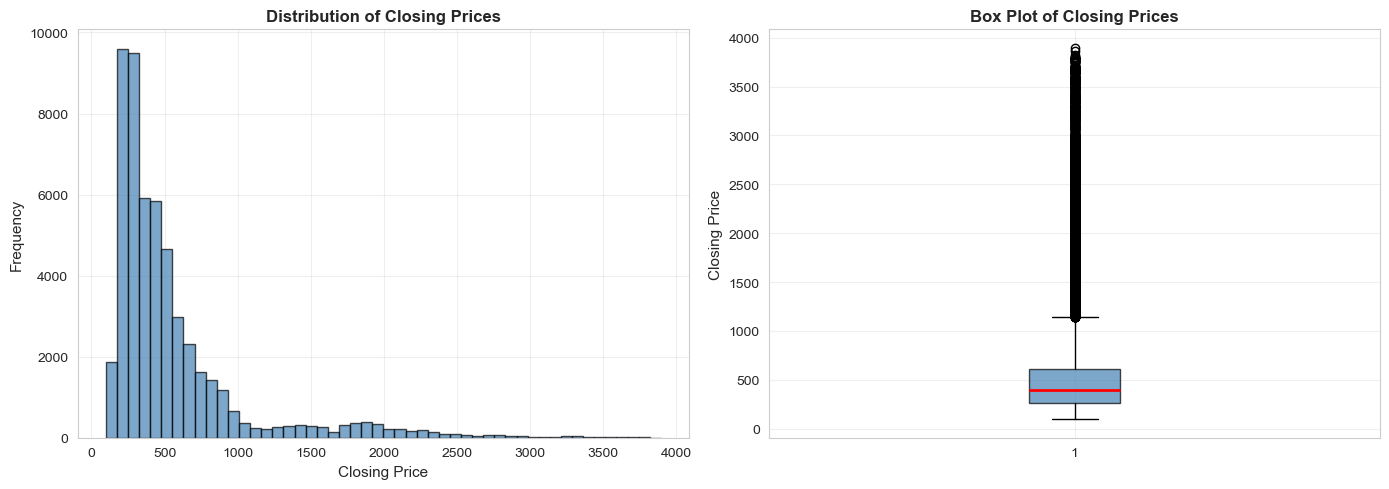

Mean closing price: 559.52
Median closing price: 398.00
Std closing price: 511.40


In [8]:
# Distribution of closing prices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(data['close'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Distribution of Closing Prices', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Closing Price', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].grid(alpha=0.3)

# Box plot
axes[1].boxplot(data['close'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.7),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Box Plot of Closing Prices', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Closing Price', fontsize=11)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Mean closing price: {data['close'].mean():.2f}")
print(f"Median closing price: {data['close'].median():.2f}")
print(f"Std closing price: {data['close'].std():.2f}")

## 6. Price Range by Bank

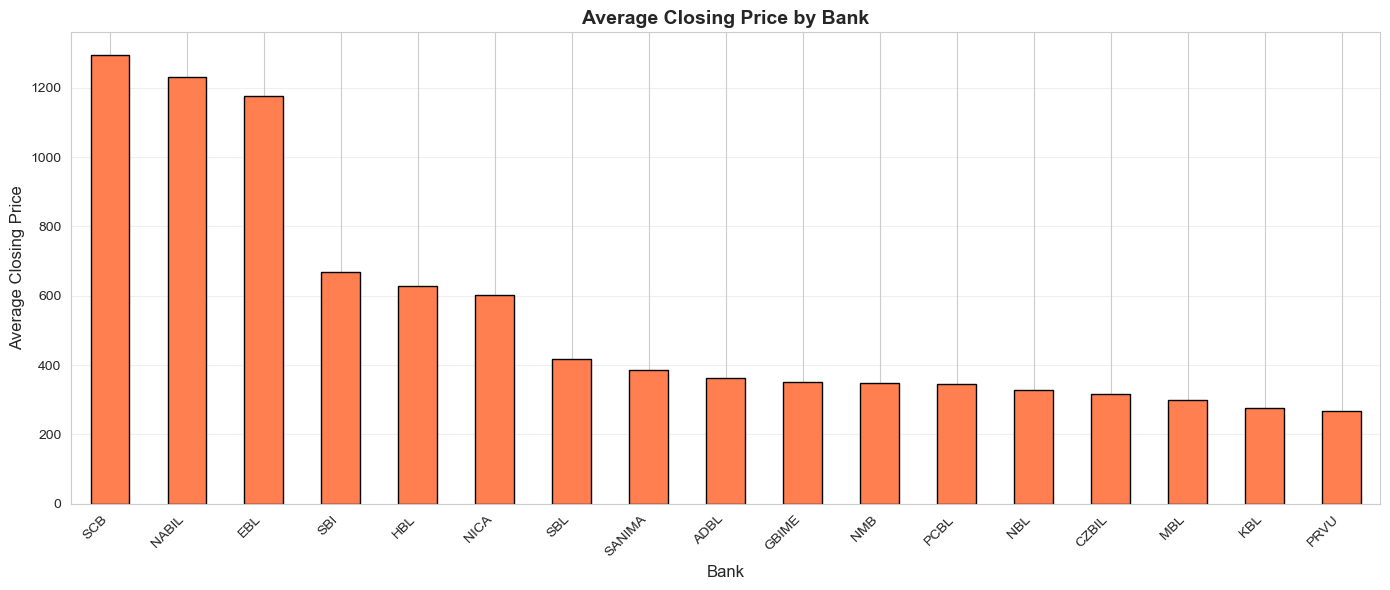

In [9]:
# Average closing price per bank
avg_price_by_bank = data.groupby('company_id')['close'].mean().sort_values(ascending=False)

plt.figure(figsize=(14, 6))
avg_price_by_bank.plot(kind='bar', color='coral', edgecolor='black')
plt.title('Average Closing Price by Bank', fontsize=14, fontweight='bold')
plt.xlabel('Bank', fontsize=12)
plt.ylabel('Average Closing Price', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Temporal Trends

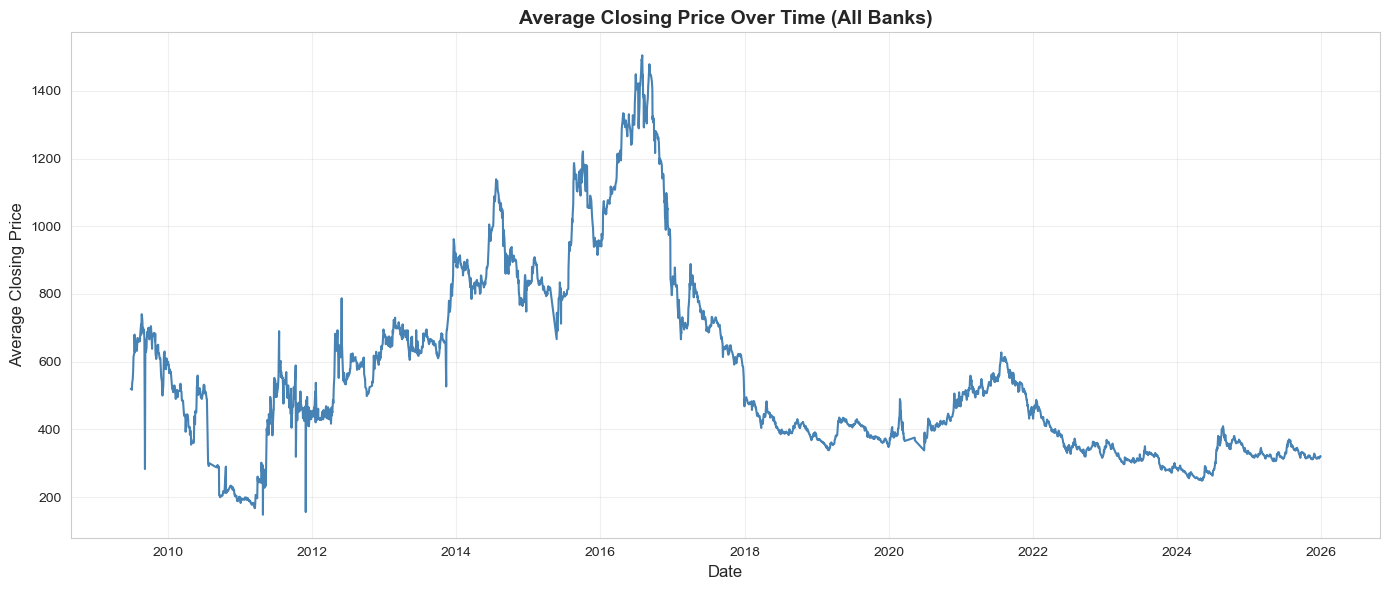

In [11]:
# Overall price trend over time
daily_avg = data.groupby('published_date')['close'].mean()

plt.figure(figsize=(14, 6))
plt.plot(daily_avg.index, daily_avg.values, linewidth=1.5, color='steelblue')
plt.title('Average Closing Price Over Time (All Banks)', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Average Closing Price', fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

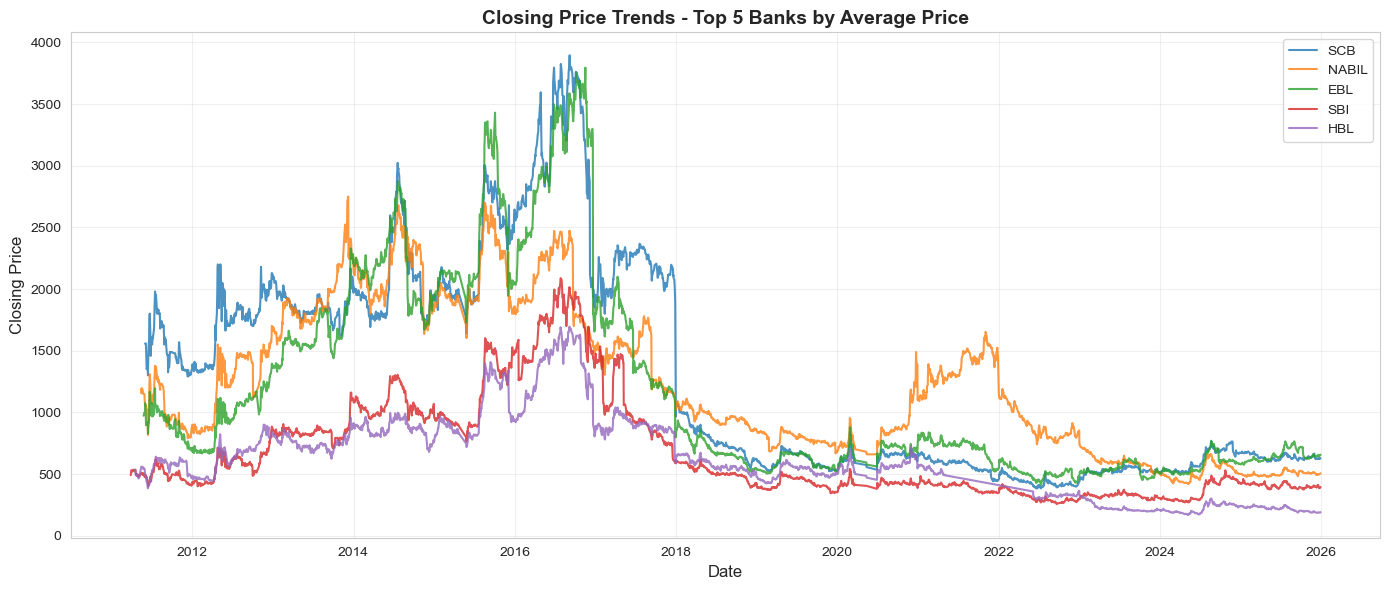

In [12]:
# Price trend for top 5 banks by average price
top_5_banks = avg_price_by_bank.head(5).index

plt.figure(figsize=(14, 6))

for bank in top_5_banks:
    bank_data = data[data['company_id'] == bank]
    plt.plot(bank_data['published_date'], bank_data['close'], label=bank, linewidth=1.5, alpha=0.8)

plt.title('Closing Price Trends - Top 5 Banks by Average Price', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Closing Price', fontsize=12)
plt.legend(loc='best', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Volume Analysis

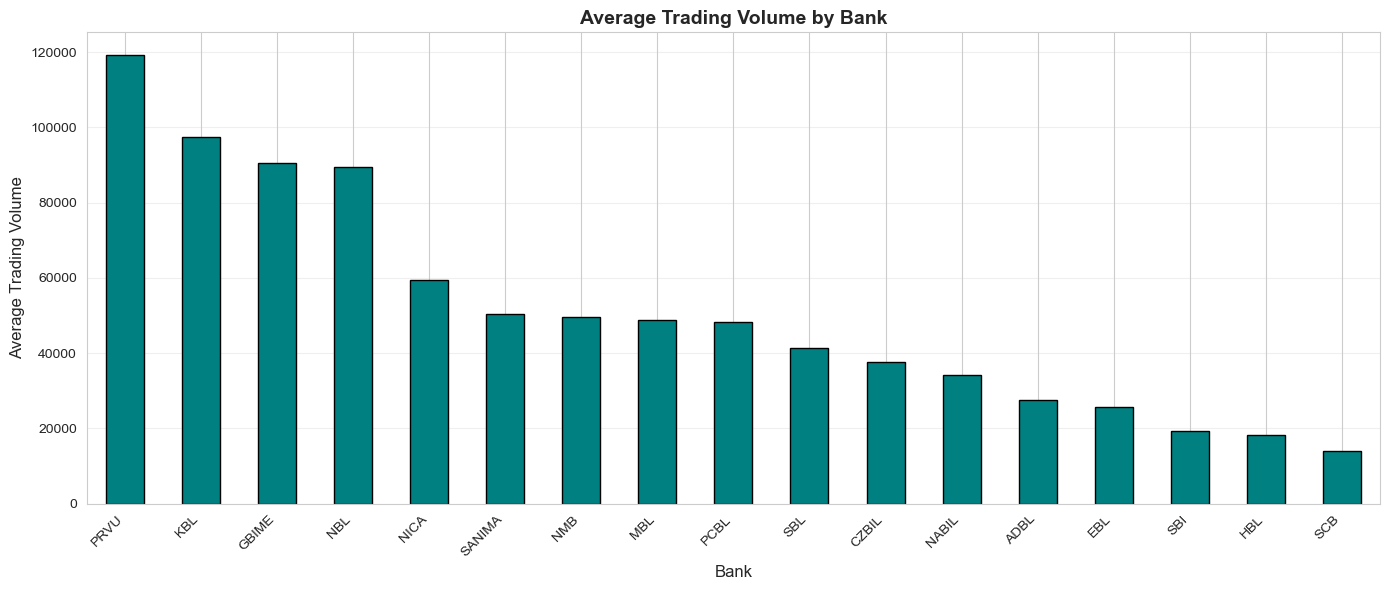

In [14]:
# Average trading volume per bank
avg_volume_by_bank = data.groupby('company_id')['traded_quantity'].mean().sort_values(ascending=False)

plt.figure(figsize=(14, 6))
avg_volume_by_bank.plot(kind='bar', color='teal', edgecolor='black')
plt.title('Average Trading Volume by Bank', fontsize=14, fontweight='bold')
plt.xlabel('Bank', fontsize=12)
plt.ylabel('Average Trading Volume', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Price-Volume Relationship

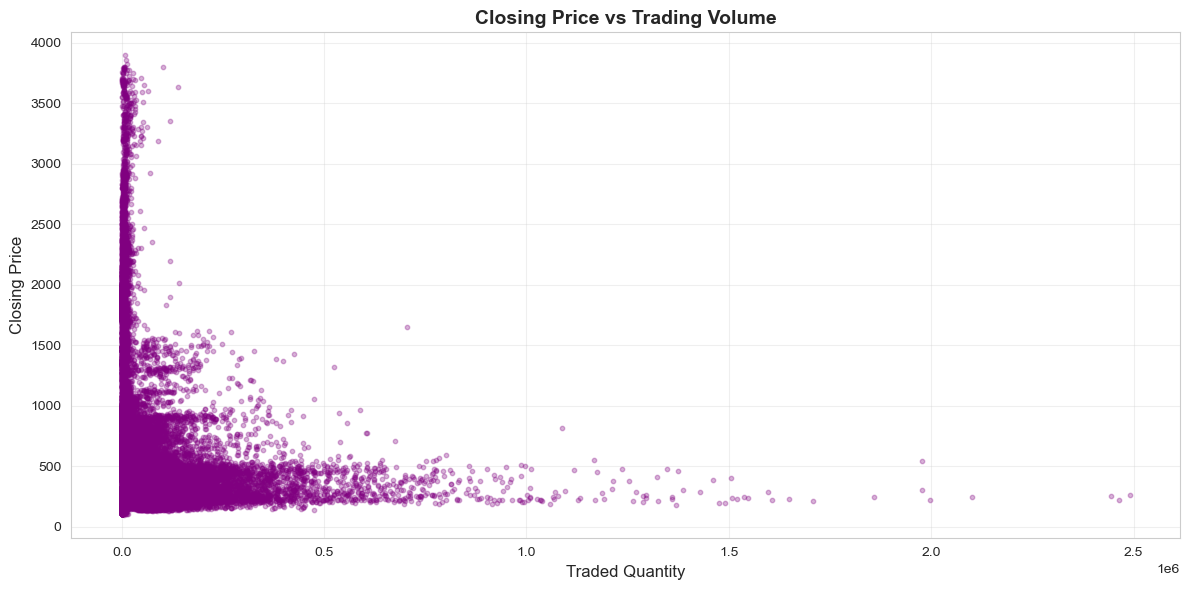

Correlation between closing price and trading volume: -0.1506


In [15]:
# Scatter plot: Price vs Volume
plt.figure(figsize=(12, 6))
plt.scatter(data['traded_quantity'], data['close'], alpha=0.3, s=10, color='purple')
plt.title('Closing Price vs Trading Volume', fontsize=14, fontweight='bold')
plt.xlabel('Traded Quantity', fontsize=12)
plt.ylabel('Closing Price', fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Calculate correlation
correlation = data['close'].corr(data['traded_quantity'])
print(f"Correlation between closing price and trading volume: {correlation:.4f}")

## 10. Daily Price Change Analysis

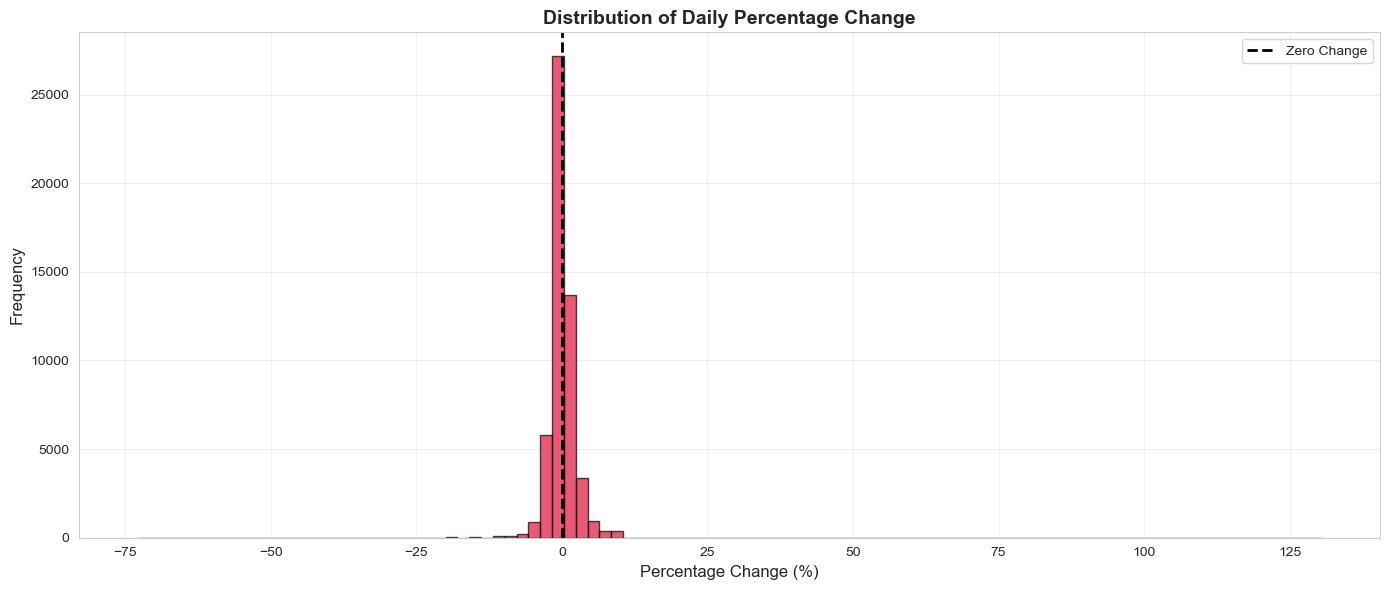

Mean percentage change: 0.0345%
Std percentage change: 2.3627%
Positive changes: 22554 (42.50%)
Negative changes: 26456 (49.86%)


In [16]:
# Distribution of percentage change
plt.figure(figsize=(14, 6))
plt.hist(data['per_change'].dropna(), bins=100, color='crimson', edgecolor='black', alpha=0.7)
plt.axvline(x=0, color='black', linestyle='--', linewidth=2, label='Zero Change')
plt.title('Distribution of Daily Percentage Change', fontsize=14, fontweight='bold')
plt.xlabel('Percentage Change (%)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Mean percentage change: {data['per_change'].mean():.4f}%")
print(f"Std percentage change: {data['per_change'].std():.4f}%")
print(f"Positive changes: {(data['per_change'] > 0).sum()} ({(data['per_change'] > 0).sum() / len(data) * 100:.2f}%)")
print(f"Negative changes: {(data['per_change'] < 0).sum()} ({(data['per_change'] < 0).sum() / len(data) * 100:.2f}%)")

## 11. OHLC Analysis

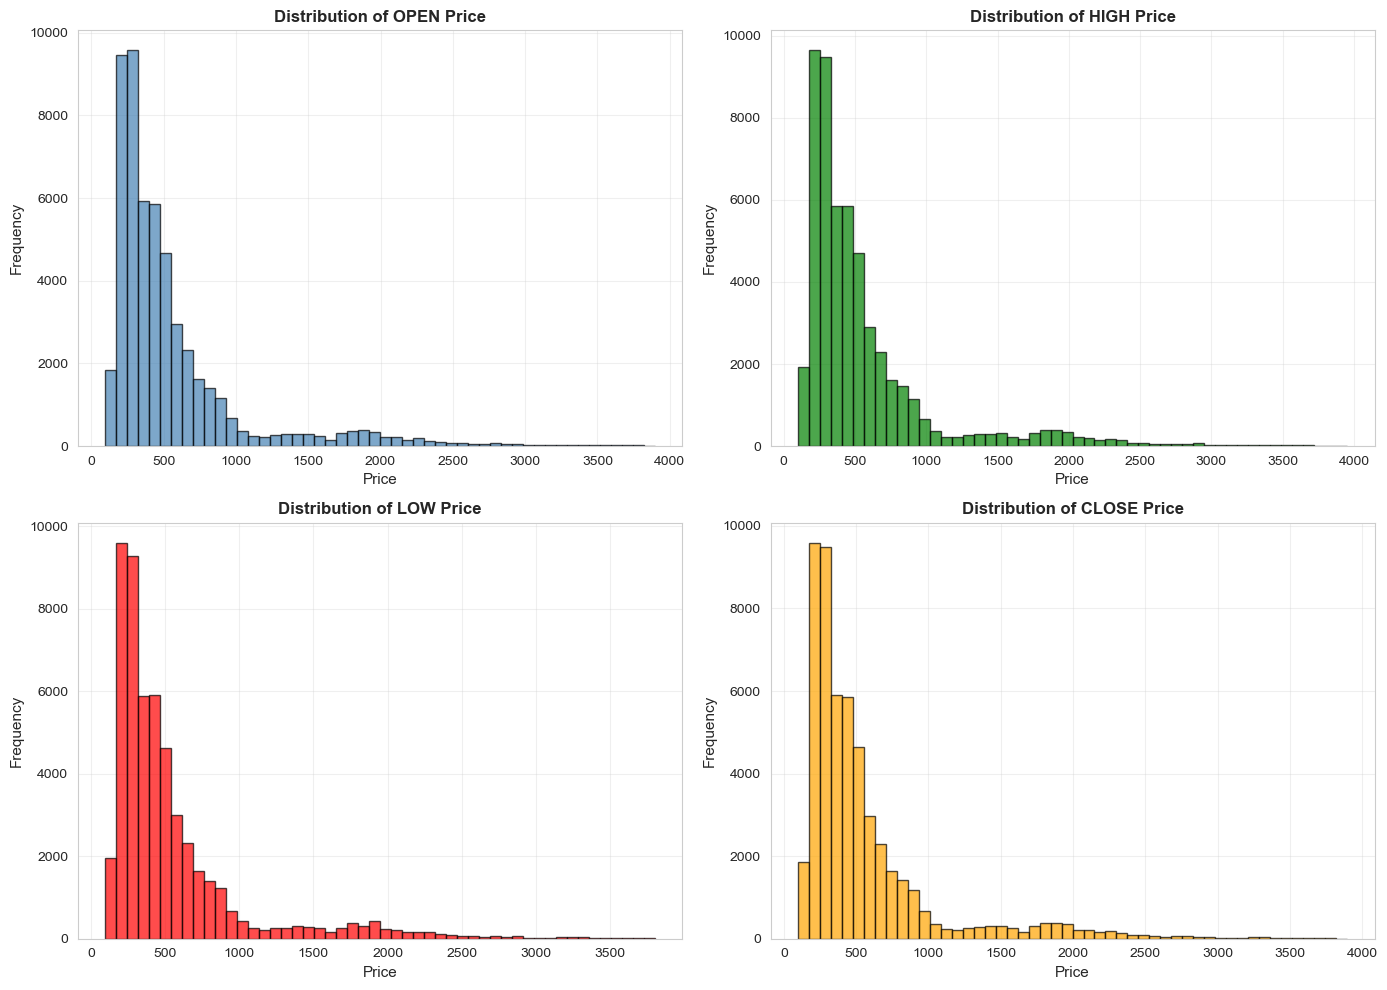

In [17]:
# Open, High, Low, Close comparison
ohlc_cols = ['open', 'high', 'low', 'close']
ohlc_data = data[ohlc_cols]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
colors = ['steelblue', 'green', 'red', 'orange']

for idx, (col, ax, color) in enumerate(zip(ohlc_cols, axes.flatten(), colors)):
    ax.hist(data[col], bins=50, color=color, edgecolor='black', alpha=0.7)
    ax.set_title(f'Distribution of {col.upper()} Price', fontsize=12, fontweight='bold')
    ax.set_xlabel('Price', fontsize=11)
    ax.set_ylabel('Frequency', fontsize=11)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

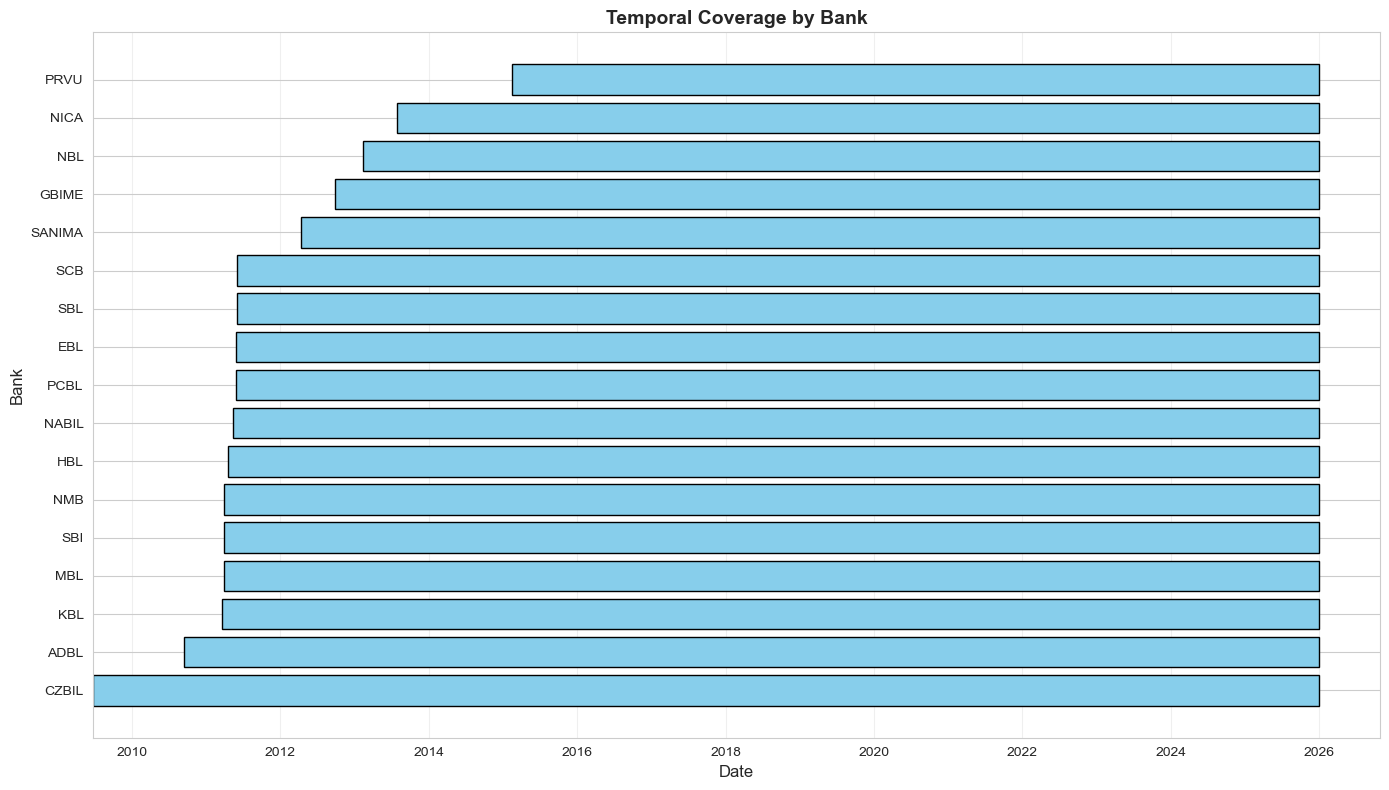

In [25]:
# Visualize temporal coverage
fig, ax = plt.subplots(figsize=(14, 8))

for idx, bank in enumerate(date_coverage.index):
    bank_data = date_coverage.loc[bank]
    ax.barh(idx, bank_data['days_span'], left=bank_data['min'], 
            height=0.8, color='skyblue', edgecolor='black')

ax.set_yticks(range(len(date_coverage)))
ax.set_yticklabels(date_coverage.index)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Bank', fontsize=12)
ax.set_title('Temporal Coverage by Bank', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()